In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [2]:
data_path = r'C:\Users\user\Desktop\ecommerce-analytics-project\data\ecommerce_data.csv'
df = pd.read_csv(data_path, parse_dates=['order_date'])

print(f"✅ Data loaded: {len(df):,} orders")
print(df.head())

✅ Data loaded: 5,000 orders
   order_id customer_id                    order_date order_status  \
0  ORD00001    CUST1127 2023-01-01 00:00:00.000000000    Delivered   
1  ORD00002    CUST1460 2023-01-01 03:30:16.923384676    Delivered   
2  ORD00003    CUST0861 2023-01-01 07:00:33.846769353      Shipped   
3  ORD00004    CUST1295 2023-01-01 10:30:50.770154030    Delivered   
4  ORD00005    CUST1131 2023-01-01 14:01:07.693538707    Delivered   

   total_amount payment_method product_category   customer_city  \
0        208.44     Debit Card            Books        Salvador   
1        184.17         PayPal            Books  Rio de Janeiro   
2        419.47    Credit Card      Electronics       Sao Paulo   
3        151.90           Cash    Home & Garden       Sao Paulo   
4        371.91    Credit Card      Electronics       Fortaleza   

   customer_rating  delivery_days  
0                4             13  
1                2             11  
2                4              5  
3   

In [3]:
total_revenue = df['total_amount'].sum()
avg_order = df['total_amount'].mean()
total_customers = df['customer_id'].nunique()
delivery_success = (df['order_status'] == 'Delivered').sum() / len(df) * 100

print("="*50)
print("📊 KEY METRICS")
print("="*50)
print(f"💰 Total Revenue:     ${total_revenue:,.2f}")
print(f"🛒 Avg Order Value:   ${avg_order:.2f}")
print(f"👥 Unique Customers:  {total_customers:,}")
print(f"✅ Delivery Success:  {delivery_success:.1f}%")
print(f"⭐ Average Rating:    {df['customer_rating'].mean():.2f}/5.0")

📊 KEY METRICS
💰 Total Revenue:     $1,304,477.19
🛒 Avg Order Value:   $260.90
👥 Unique Customers:  1,790
✅ Delivery Success:  85.2%
⭐ Average Rating:    4.14/5.0


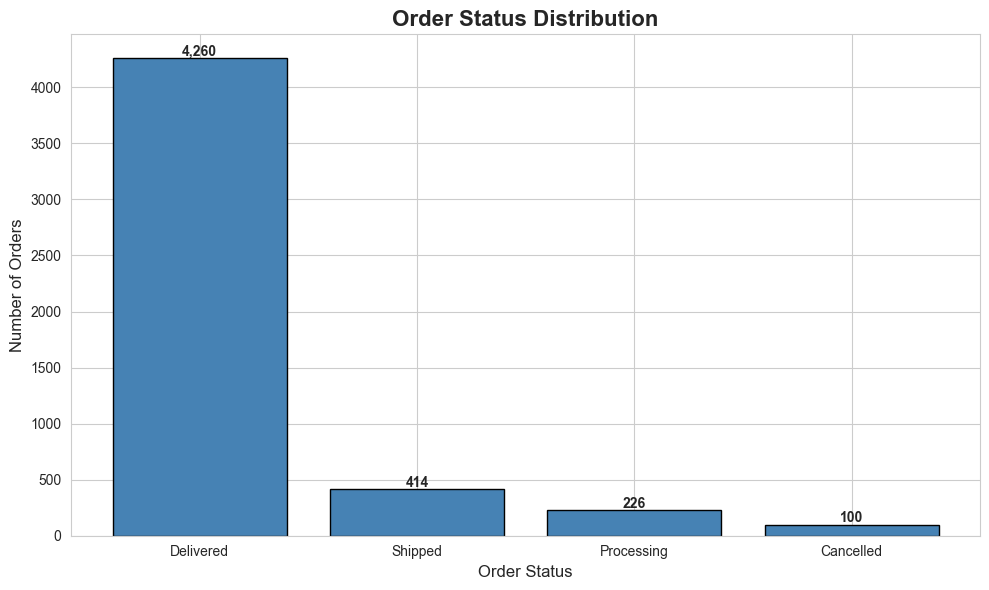

✅ Chart 1 done!


In [4]:
plt.figure(figsize=(10, 6))
status_counts = df['order_status'].value_counts()

plt.bar(status_counts.index, status_counts.values,
        color='steelblue', edgecolor='black')
plt.title('Order Status Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Order Status', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)

for i, v in enumerate(status_counts.values):
    plt.text(i, v + 20, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(r'C:\Users\user\Desktop\ecommerce-analytics-project\data\chart1_order_status.png')
plt.show()
print("✅ Chart 1 done!")

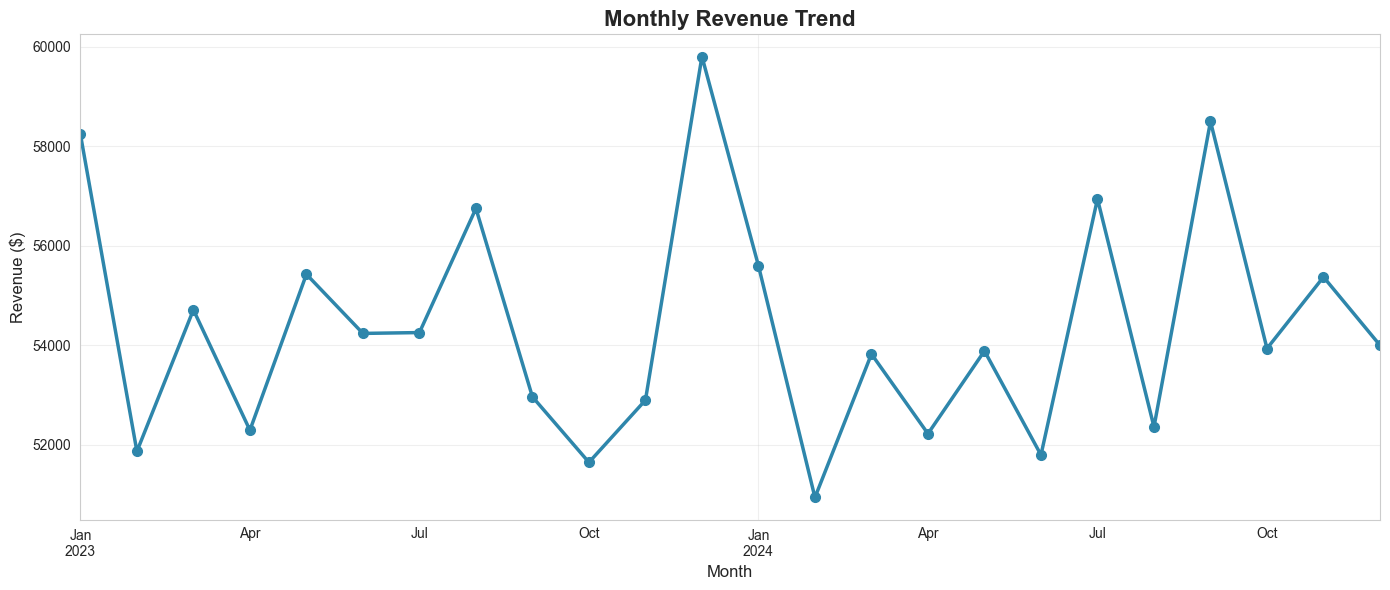

✅ Chart 2 done!
📈 Best month: 2023-12 — $59,806.25


In [5]:
df['year_month'] = df['order_date'].dt.to_period('M')
monthly_revenue = df.groupby('year_month')['total_amount'].sum()

plt.figure(figsize=(14, 6))
monthly_revenue.plot(kind='line', marker='o',
                     color='#2E86AB', linewidth=2.5, markersize=7)
plt.title('Monthly Revenue Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(r'C:\Users\user\Desktop\ecommerce-analytics-project\data\chart2_monthly_revenue.png')
plt.show()

print(f"✅ Chart 2 done!")
print(f"📈 Best month: {monthly_revenue.idxmax()} — ${monthly_revenue.max():,.2f}")

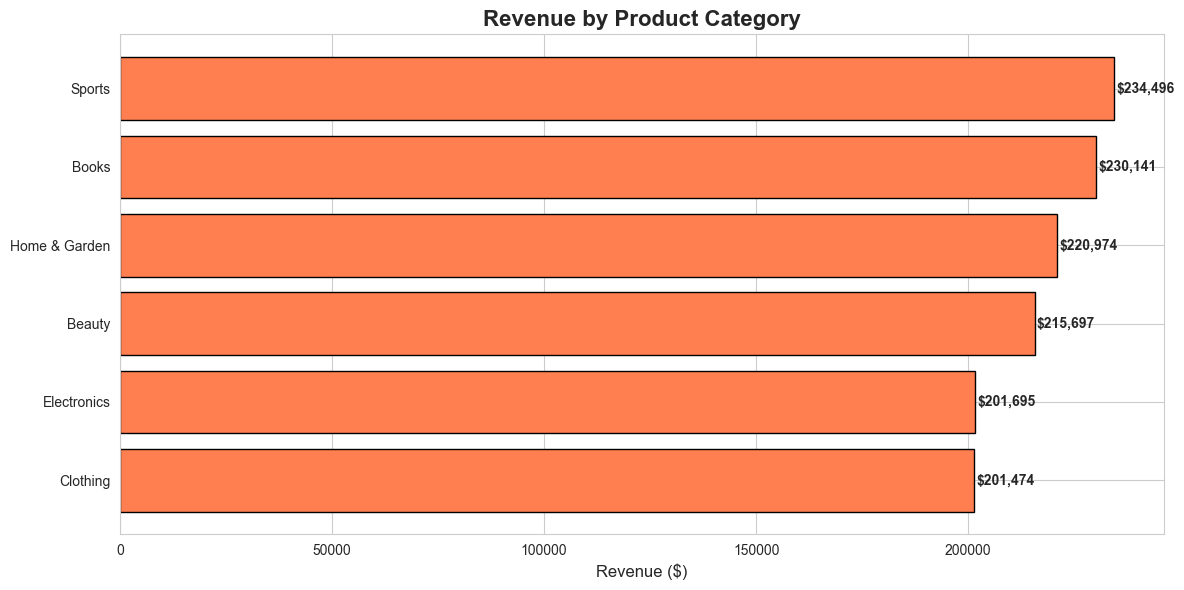

✅ Chart 3 done!


In [6]:
category_revenue = df.groupby('product_category')['total_amount'].sum().sort_values()

plt.figure(figsize=(12, 6))
plt.barh(category_revenue.index, category_revenue.values,
         color='coral', edgecolor='black')
plt.title('Revenue by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Revenue ($)', fontsize=12)

for i, v in enumerate(category_revenue.values):
    plt.text(v + 500, i, f'${v:,.0f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(r'C:\Users\user\Desktop\ecommerce-analytics-project\data\chart3_categories.png')
plt.show()
print("✅ Chart 3 done!")

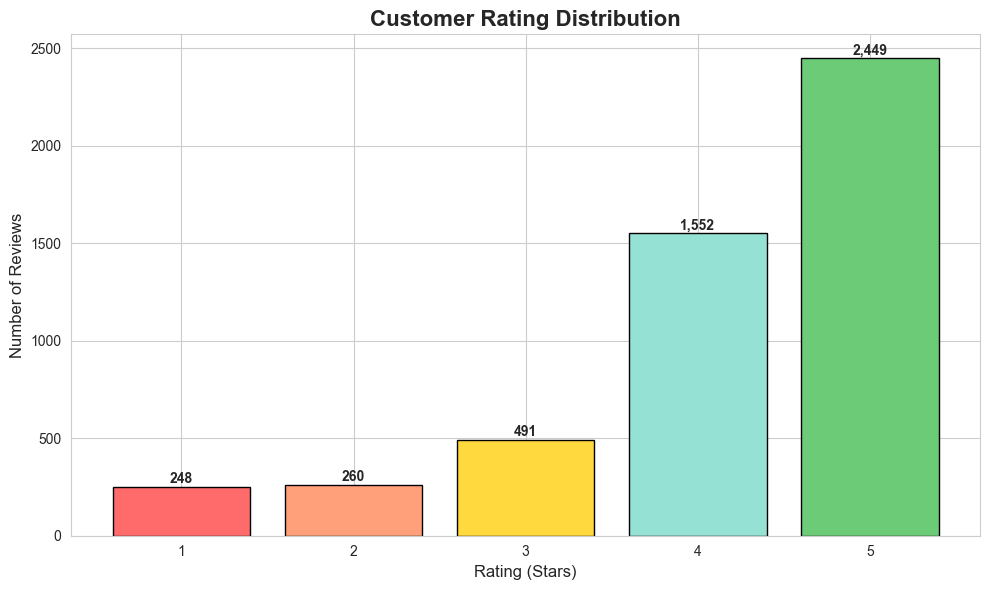

✅ Chart 4 done!


In [7]:
rating_counts = df['customer_rating'].value_counts().sort_index()
colors = ['#FF6B6B', '#FFA07A', '#FFD93D', '#95E1D3', '#6BCB77']

plt.figure(figsize=(10, 6))
plt.bar(rating_counts.index, rating_counts.values,
        color=colors, edgecolor='black')
plt.title('Customer Rating Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Rating (Stars)', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.xticks([1, 2, 3, 4, 5])

for rating, count in rating_counts.items():
    plt.text(rating, count + 20, f'{count:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(r'C:\Users\user\Desktop\ecommerce-analytics-project\data\chart4_ratings.png')
plt.show()
print("✅ Chart 4 done!")

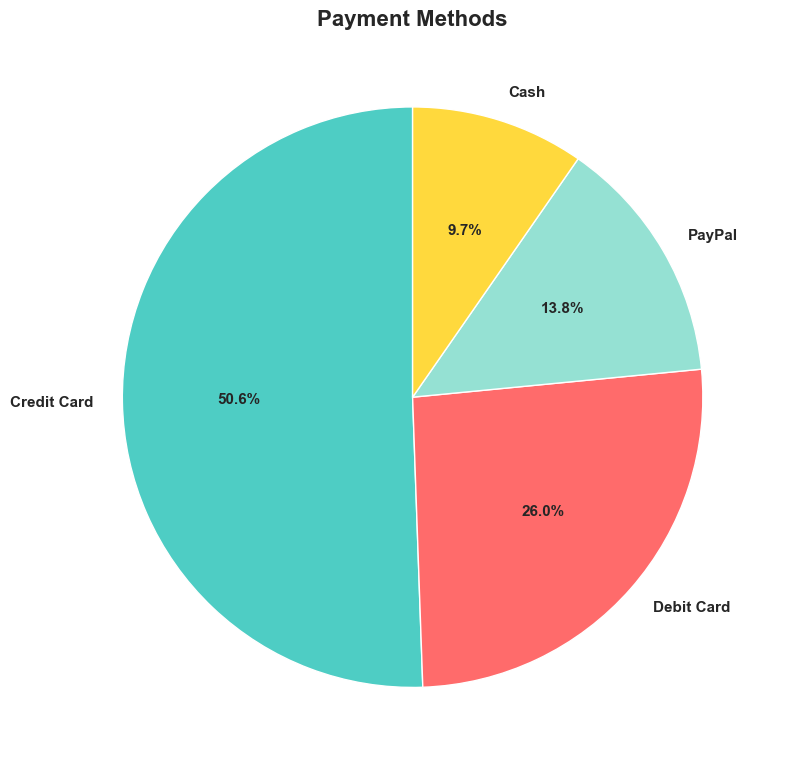

✅ Chart 5 done!


In [8]:
payment_dist = df['payment_method'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(payment_dist.values, labels=payment_dist.index,
        autopct='%1.1f%%',
        colors=['#4ECDC4', '#FF6B6B', '#95E1D3', '#FFD93D'],
        startangle=90,
        textprops={'fontsize': 11, 'fontweight': 'bold'})
plt.title('Payment Methods', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\user\Desktop\ecommerce-analytics-project\data\chart5_payments.png')
plt.show()
print("✅ Chart 5 done!")

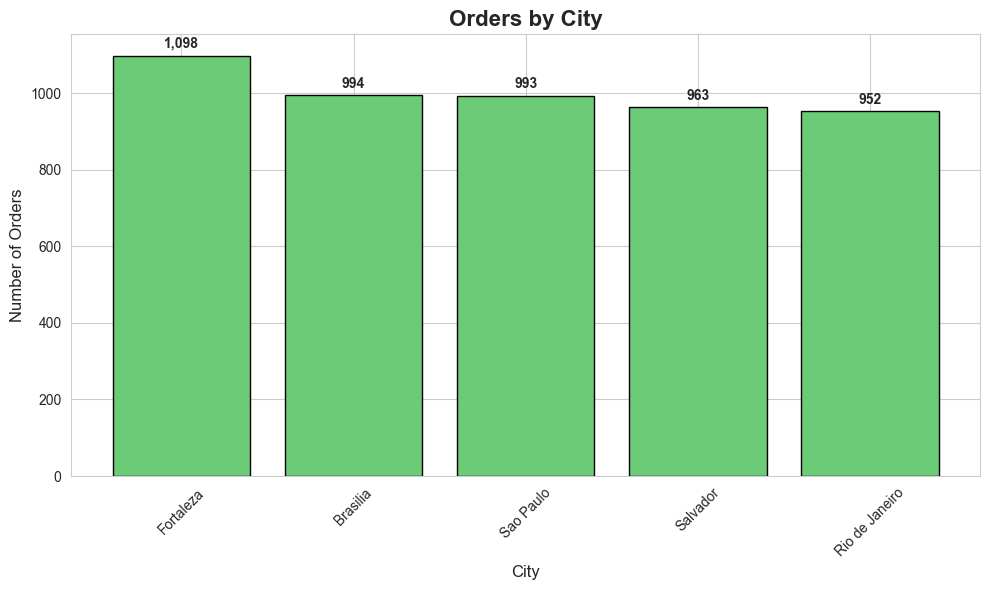

✅ Chart 6 done!


In [9]:
top_cities = df['customer_city'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(top_cities.index, top_cities.values,
        color='#6BCB77', edgecolor='black')
plt.title('Orders by City', fontsize=16, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=45)

for i, v in enumerate(top_cities.values):
    plt.text(i, v + 20, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(r'C:\Users\user\Desktop\ecommerce-analytics-project\data\chart6_cities.png')
plt.show()
print("✅ Chart 6 done!")